In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

lme = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'patients_lme_DTI.tsv'), sep = '\t')
lme['Week'] = lme['Week'].astype(int)
lme = lme.sort_values('Week')

# observed values
obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
obs = obs[obs.metric == 'FaMap']

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
obs = obs[~obs.subj_id.isin(controls)]

obs['region_bilat'] = obs['Object'].str[:3]
# all lesions flipped to the right
obs.loc[(obs.Object.str[-1] == 'L'), 'side'] = 'contralesional'
obs.loc[(obs.Object.str[-1] == 'R'), 'side'] = 'ipsilesional'


/localscratch/tmp/ipykernel_39434/4069241100.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


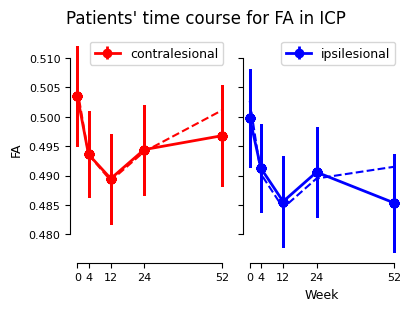

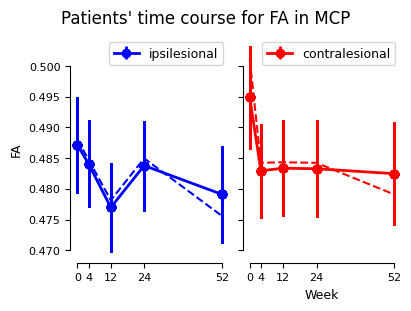

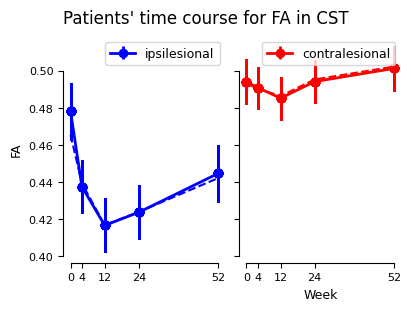

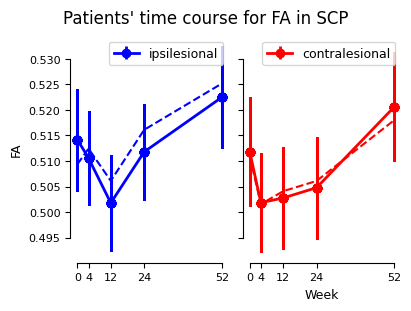

In [3]:
colours = ['red', 'blue']
for r, region in enumerate(lme.region_bilat.unique()):
    region_lme = lme[lme.region_bilat == region].sort_values('Week')
    region_obs = obs[obs.region_bilat == region].sort_values('week_num')
    
    fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

    for i, side in enumerate(region_lme.side.unique()):
        ax = axs[i]
        if side == 'ipsilesional':
            colour = 'blue'
        if side == 'contralesional':
            colour = 'red'

        region_lme_side = region_lme[region_lme.side == side].sort_values("Week")
        region_obs_side = region_obs[region_obs.side == side].sort_values("week_num")
        region_obs_side = region_obs_side.groupby(["week_num"]).agg({'Mean': 'mean'}).reset_index()
        
        ax.errorbar(x = region_lme_side['Week'], y = region_lme_side['beta'], yerr = region_lme_side['se'], fmt = '-o', linewidth = 2, color = colour, label = side)
        ax.plot(region_obs_side['week_num'], region_obs_side['Mean'], linestyle = '--', color = colour)


    for ax in axs:
        ax.legend()
        ax.set_xticks(gl.weeks)
        axs[0].set_ylabel("FA")
        axs[1].set_xlabel("Week")
    
    plt.suptitle(f"Patients' time course for FA in {region}")
    sns.despine(trim = True)
    plt.show()